<a href="https://colab.research.google.com/github/kirtiii2008/SOS/blob/main/Real_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

epoch1 Train Loss-> 0.6359183938454485 Test Accuracy -> 68.544% Train Accuracy-> 69.288%
epoch2 Train Loss-> 0.552203632681571 Test Accuracy -> 75.112% Train Accuracy-> 77.832%
epoch3 Train Loss-> 0.5794797825538899 Test Accuracy -> 72.164% Train Accuracy-> 75.224%
epoch4 Train Loss-> 0.48834967346447505 Test Accuracy -> 77.276% Train Accuracy-> 81.528%
epoch5 Train Loss-> 0.36924282539531095 Test Accuracy -> 82.852% Train Accuracy-> 87.268%
epoch6 Train Loss-> 0.29677764484492103 Test Accuracy -> 83.876% Train Accuracy-> 90.104%
epoch7 Train Loss-> 0.2470554798993918 Test Accuracy -> 86.2% Train Accuracy-> 92.516%
epoch8 Train Loss-> 0.19609637050639334 Test Accuracy -> 87.252% Train Accuracy-> 94.476%
epoch9 Train Loss-> 0.1674713293457275 Test Accuracy -> 87.516% Train Accuracy-> 95.708%
epoch10 Train Loss-> 0.14193902451001927 Test Accuracy -> 87.264% Train Accuracy-> 96.236%


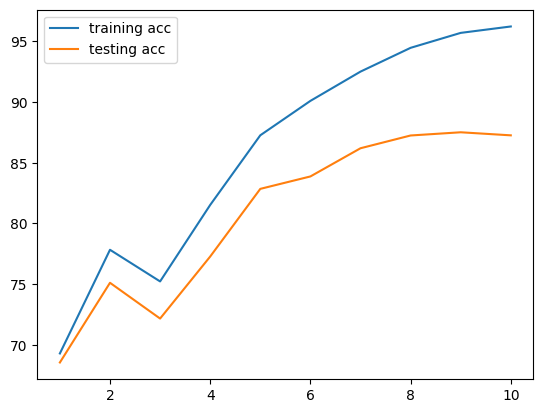

In [10]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("stanfordnlp/imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

def build_vocab():

    if os.path.exists("sentiment_vocab"):
        vocab = torch.load("sentiment_vocab")
        return vocab
    else:
        vocab = {
            "<PAD>":0,
            "<UNKNOWN>":1
        }
        word_num = 2
        temp = {

        }
        for data in train_data:
            text = data["text"]
            text = text.replace("."," . ")
            text = text.replace("!"," ! ")
            text = text.replace(","," , ")
            text = text.replace("<br /><br />", "")
            words_splited = text.split()
            for word in words_splited:
                word = word.lower()
                if word not in temp:
                    temp[word] = 1
                else:
                    temp[word]+=1
        for words in temp:
            if temp[words] > 10 and words not in vocab:
                vocab[words] = len(vocab)
        torch.save(vocab,"sentiment_vocab")
        return vocab

vocab = build_vocab()

def preprocess(review):
    review = review.replace(".", " . ")
    review = review.replace("!", " ! ")
    review = review.replace(",", " , ")
    review = review.replace("<br /><br />", "")
    return review

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.dropout = nn.Dropout(p=0.3)
        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1,  #num of layers in lstm
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x,lengths):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        packed_x = pack_padded_sequence(x,lengths.cpu(),batch_first=True,enforce_sorted=False)
        out , (hn,cn) = self.lstm(packed_x)
        drop_out = self.dropout(hn[-1]) # means from the taken the 2d matrix batch_size,hidden_size from last lstm layer
        return self.fc(drop_out) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []
true_lens_train = []
for batch in train_dataloader:
    input_text = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))
    true_lens_train.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []
true_lens_test = []
for batch in test_dataloader:
    inp = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))
    true_lens_test.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out,true_lengths):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs,true_lengths[i]))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []
if os.path.exists("real_sentiment_params"):
   model.load_state_dict(torch.load("real_sentiment_params"))
#trainingggg
train_num = 10
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs,true_lens_train[j])
          loss = loss_function(model_pred, labels)

          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data,true_lengths=true_lens_test)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data,true_lengths=true_lens_train)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"Train Accuracy-> {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

arr = np.arange(1,train_num+1)
train_acc = np.array(train_acc)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.legend(loc='upper left')
plt.show()

